# Solar Filament Segmentation Challenge 2026
## U-Net + ConvNeXt training, evaluation, and inference

This notebook is the pipeline driver: it installs the extra deep-learning
dependencies, points the shared config at Kaggle's `/kaggle/input` mounts,
then calls the same `scripts/train.py` / `scripts/evaluate.py` / `scripts/infer.py`
used locally -- so the logic lives in one place (the code dataset attached to
this kernel), not duplicated into notebook cells.

**Task**: binary, category-agnostic filament segmentation (the competition's
Overview page states class labels are out of scope for scoring). A U-Net with a
ConvNeXt-Tiny encoder predicts a foreground probability map; watershed
post-processing splits it into individual filament instances for the
Panoptic-Quality-scored submission format.

### 0. Confirm the mounted data layout
Adjust `configs/config_kaggle.yaml`'s `data:` paths if this doesn't match.

In [1]:
!git clone https://github.com/jprakash-1/Solar-Filament-Segmentation.git

fatal: destination path 'Solar-Filament-Segmentation' already exists and is not an empty directory.


In [1]:
%cd /kaggle/working/Solar-Filament-Segmentation
!ls

/kaggle/working/Solar-Filament-Segmentation
configs		 memory.md	   scripts
data		 outputs	   solar-filament-segmentation-analysis.ipynb
kaggle_notebook  README.md	   src
kaggle_package	 requirements.txt  state.db


In [2]:
!find /kaggle/input -maxdepth 3

/kaggle/input
/kaggle/input/competitions
/kaggle/input/competitions/filament-segmentation-2026
/kaggle/input/competitions/filament-segmentation-2026/MAGFiLO_1.0_Kaggle_2026


### 1. Bring in the code dataset and install missing dependencies

In [12]:
!git pull origin master 

remote: Enumerating objects: 9, done.
remote: Counting objects: 100% (9/9), done.
remote: Compressing objects: 100% (1/1), done.
remote: Total 5 (delta 4), reused 5 (delta 4), pack-reused 0 (from 0)
Unpacking objects: 100% (5/5), 1.24 KiB | 181.00 KiB/s, done.
From https://github.com/jprakash-1/Solar-Filament-Segmentation
 * branch            master     -> FETCH_HEAD
   a654e84..8187e1a  master     -> origin/master
Updating a654e84..8187e1a
Fast-forward
 scripts/visualize_train_predictions.py     | 11 ++++++-----
 solar-filament-segmentation-analysis.ipynb |  4 ++--
 2 files changed, 8 insertions(+), 7 deletions(-)


In [4]:
!pip install -q -r requirements.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 4.1 MB/s eta 0:00:0000:01


In [5]:
import torch
print('torch', torch.__version__)
print('cuda available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('device:', torch.cuda.get_device_name(0))

torch 2.10.0+cu128
cuda available: True
device: Tesla T4


### 2. Train
`configs/config_kaggle.yaml` sets `image_size: 2048` (native resolution) and a GPU-sized
`batch_size` (default 4 -- raise/lower depending on VRAM). Override any config value
from the CLI, e.g. `--epochs` / `--batch-size`, without editing the file.

In [ ]:
!torchrun --nproc_per_node=$(python -c "import torch; print(max(1, torch.cuda.device_count()))") \
    scripts/train.py --config configs/config_kaggle.yaml

### 3. Training curve

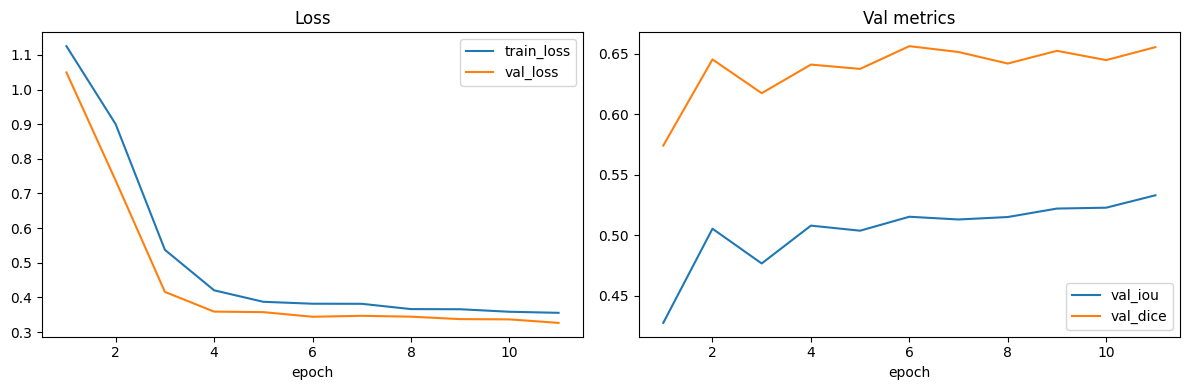

In [6]:
import pandas as pd
import matplotlib.pyplot as plt


log = pd.read_csv('outputs/logs/20260822_171011_small_img1536_bs4_gc/train_log.csv')
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(log['epoch'], log['train_loss'], label='train_loss')
axes[0].plot(log['epoch'], log['val_loss'], label='val_loss')
axes[0].set_xlabel('epoch'); axes[0].legend(); axes[0].set_title('Loss')
axes[1].plot(log['epoch'], log['val_iou'], label='val_iou')
axes[1].plot(log['epoch'], log['val_dice_torchmetrics'], label='val_dice')
axes[1].set_xlabel('epoch'); axes[1].legend(); axes[1].set_title('Val metrics')
fig.tight_layout()
plt.show()

### 4. Evaluate (instance-level Panoptic Quality + Dice)
Runs the full inference + post-processing pipeline against the held-out val split's
ground truth -- the same instance-splitting logic used for the actual submission --
as a local sanity check against the competition's real leaderboard metric.

In [7]:
!python scripts/evaluate.py --checkpoint outputs/checkpoints/20260822_171011_small_img1536_bs4_gc/best.pt  --sweep-watershed-min-distance "140"

Using device: cuda  (Tesla T4)
model.safetensors: 100%|█████████████████████| 201M/201M [00:03<00:00, 66.0MB/s]
Evaluating on 115 val images (checkpoint epoch 6)
Sweep mode: will try watershed_min_distance in [140] against cached predictions
sweep: 100%|█████████████████████████████████████| 1/1 [01:47<00:00, 107.89s/it]

  watershed_min_distance    mean PQ    pred/gt instances
                     140     0.3231              829/898

Best: watershed_min_distance=140 (mean PQ=0.3231) -- computing full mAP for this config below.

Computing mAP@[.5:.95]: 829 predicted instances vs 898 ground-truth instances across 115 images, over 10 IoU thresholds -- this is the slow part (full-resolution mask matching), progress bar below.
mAP thresholds: 100%|███████████████████████████| 10/10 [00:56<00:00,  5.63s/it]
mAP computation took 56.3s

mean Dice (semantic):  0.6608
mean IoU  (semantic):  0.5058
mean Panoptic Quality: 0.3231  (IoU thresh=0.5)
mAP@[.5:.95]:          0.0965
  AP@0.50:          

### 5. Inference -> submission CSV
Predicts on the test set, splits into filament instances, RLE-encodes each one, and
writes `outputs/submissions/submission_<timestamp>.csv` in the exact
`filament_id,segmentation_rle` format the competition expects.

In [8]:
!python scripts/infer.py --checkpoint outputs/checkpoints/20260822_171011_small_img1536_bs4_gc/best.pt --visualize 10

Using device: cuda
Running inference on 180 test images
infer: 100%|██████████████████████████████████| 180/180 [04:02<00:00,  1.35s/it]
Wrote 1295 filament rows for 180 images to outputs/submissions/submission_20260823_054325.csv
Saved visualizations to outputs/eda/predictions


In [9]:
import glob
import pandas as pd

submissions = sorted(glob.glob('outputs/submissions/*.csv'))
print('Latest submission:', submissions[-1] if submissions else 'none found')
pd.read_csv(submissions[-1]).head()

Latest submission: outputs/submissions/submission_20260823_054325.csv


,filament_id,segmentation_rle
0,20110120105534Ch_1,a`Ti23mo12M201N1O1O1@IVQN7hn1LUQN6kn1MQQN4nn1?...
1,20110120105534Ch_2,TjVQ25jo12M2O0N3O000O100O1O010O1O1K5M3M3O01000...
2,20110130110334Ch_1,_XPn13jo15J5M4L3N3M2N3N2M3M3M5J3M3N2O1O1O10O2O...
3,20110130110334Ch_2,d_Pe28ho14K3N3M1O2N2iPN^Omn1l0N10O1000001O01O1...
4,20110214175414Mh_1,W]`[29eo13N2M3L3M4N1N3N1O2oNWOiRNi0Vm1ZOgRNh0W...


### 6. Spot-check a few predictions

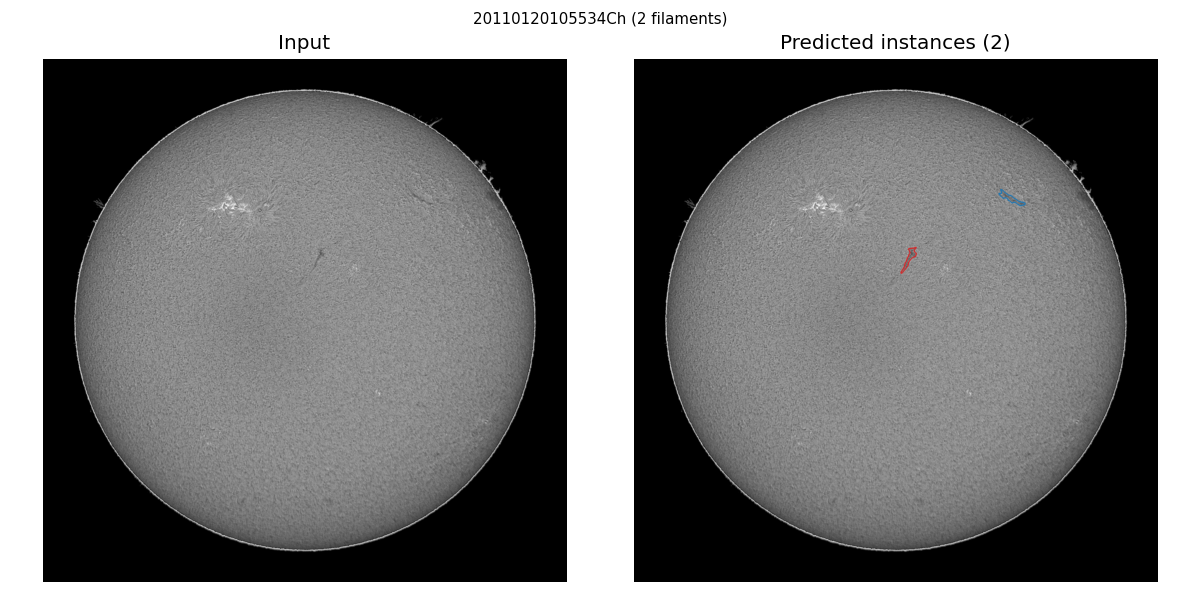

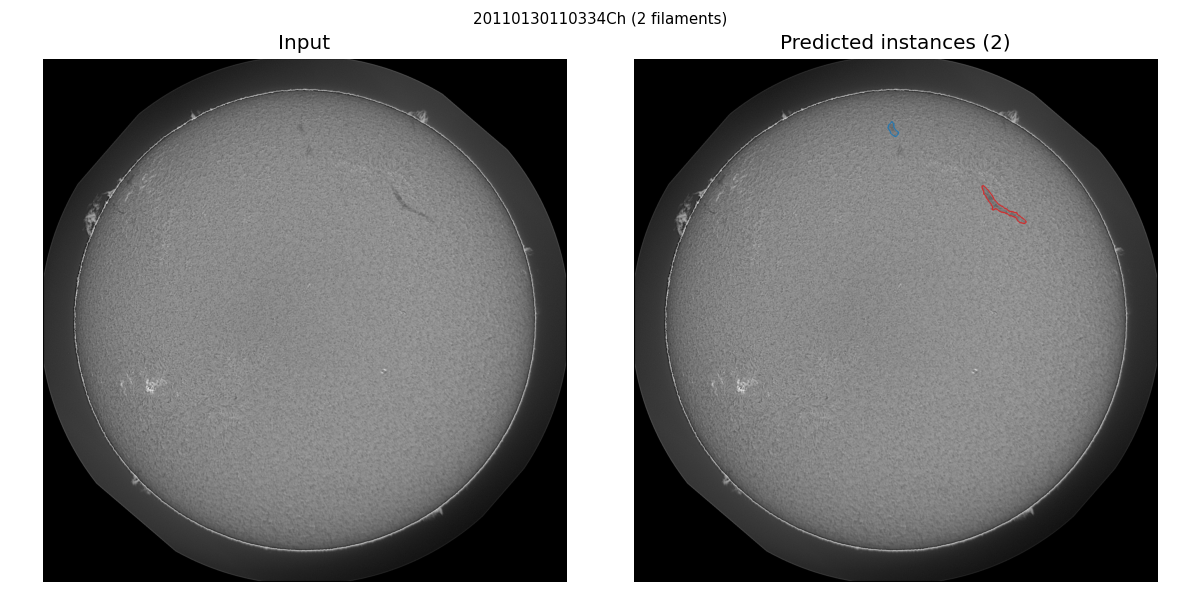

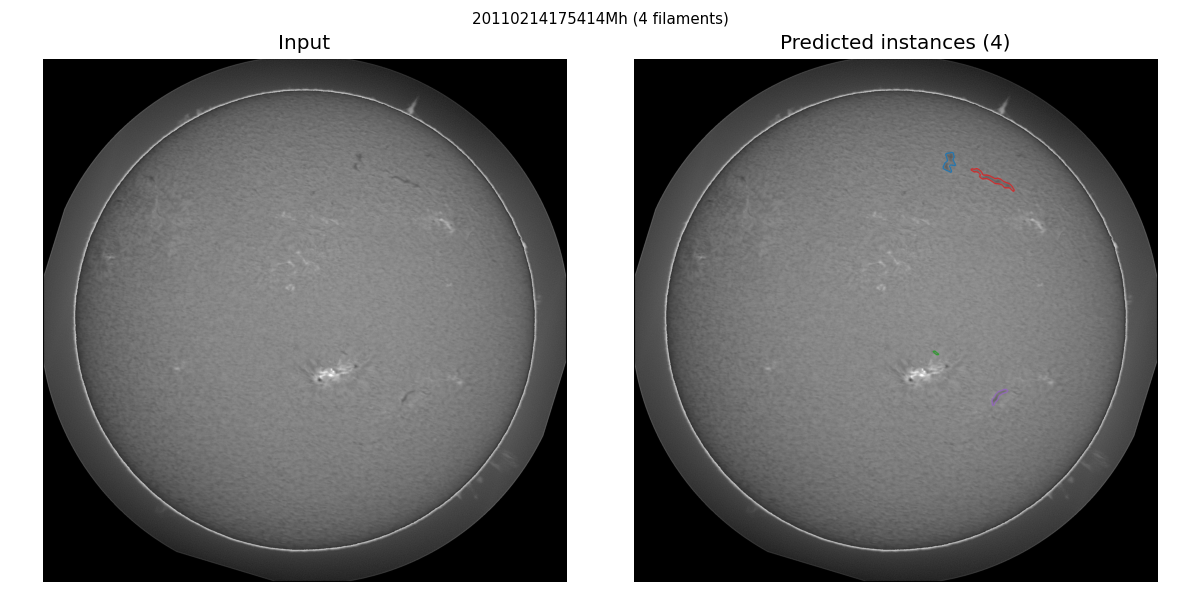

In [10]:
import glob
from PIL import Image

for path in sorted(glob.glob('outputs/eda/predictions/*.png'))[:3]:
    display(Image.open(path))

### Outputs
- `outputs/checkpoints/best.pt` / `last.pt` -- model weights
- `outputs/logs/train_log.csv` -- per-epoch metrics
- `outputs/submissions/submission_*.csv` -- ready to submit to the competition
- `outputs/eda/predictions/*.png` -- qualitative overlays (test set, no ground truth)
- `outputs/train_samples_predictions/*.png` -- input/ground-truth/predicted comparisons on
  training-set samples (also zipped to `train_samples_predictions.zip`)
- `outputs/train_analysis/` -- per-image Dice/IoU/PQ CSV, summary histograms, and
  worst/best comparison plots (also zipped to `train_analysis.zip`)

All of the above persist as this notebook's **Output** after a committed run,
downloadable via `kaggle kernels output <username>/filament-unet-convnext-training -p <local-dir>`.

In [ ]:
!ls

In [ ]:
%cd ..

In [ ]:
!zip -r  checkpoints.zip checkpoints

In [ ]:
!zip -r outputs.zip outputs/

## Output Analysis

In [13]:
!python scripts/visualize_train_predictions.py --checkpoint outputs/checkpoints/best.pt \
    --n -1 --watershed-min-distance 140

Using device: cuda
Visualizing 1039 of 1039 training images (checkpoint epoch 27)
postprocess: {'prob_threshold': 0.5, 'min_instance_area': 20, 'use_watershed': True, 'watershed_min_distance': 140}
visualize: 100%|████████████████████████████| 1039/1039 [30:25<00:00,  1.76s/it]
Done. Saved 1039 comparison plots to outputs/train_samples_predictions


In [ ]:
import glob
from PIL import Image

for path in sorted(glob.glob('outputs/train_samples_predictions/*.png'))[:5]:
    display(Image.open(path))

Zip the comparison plots for download (`kaggle kernels output` after committing this run, or via the **Output** tab). Tip for next time: launch the cell above with `!torchrun --nproc_per_node=$(python -c "import torch; print(max(1, torch.cuda.device_count()))") scripts/visualize_train_predictions.py ...` to split the 1039 images across both GPUs instead of one.

In [ ]:
!zip -r train_samples_predictions.zip outputs/train_samples_predictions

### Proper per-image analysis of training-set predictions
Computes semantic Dice/IoU and instance-level Panoptic Quality *per training image*
(not just an aggregate mean), saves them to a CSV, prints summary statistics, and
auto-generates comparison plots for the worst- and best-ranked images -- targeted
debugging instead of random spot-checks.

In [ ]:
!torchrun --nproc_per_node=$(python -c "import torch; print(max(1, torch.cuda.device_count()))") \
    scripts/analyze_train_predictions.py --checkpoint outputs/checkpoints/best.pt \
    --watershed-min-distance 140 --worst-n 15 --best-n 5

In [ ]:
import pandas as pd

metrics = pd.read_csv('outputs/train_analysis/per_image_metrics.csv')
metrics.describe()

In [ ]:
from PIL import Image

display(Image.open('outputs/train_analysis/summary.png'))

Worst-ranked images:

In [ ]:
import glob
from PIL import Image

for path in sorted(glob.glob('outputs/train_analysis/worst/*.png')):
    display(Image.open(path))

Zip the full analysis (CSV + summary + worst/best plots) for download.

In [ ]:
!zip -r train_analysis.zip outputs/train_analysis